# Подготовка модели распознавания рукописных букв и цифр

Вам предстоит самостоятельно обучить модель для задачи распознавания рукописных букв и цифр с помощью датасета `emnist`. Результатом должна быть обученная модель, сохранённая в файл `model.pkl`.

Можете воспользоваться предложенным порядком действий и подсказками из этого ноутбука или подойти к решению задачи самостоятельно и написать всё с нуля. То же касается и процесса упаковки модели в сервис для распознавания самостоятельно написанных символов.

В этом ноутбуке комментариями и символами `...` отмечены места для вашего кода.

Перед отправкой решения убедитесь, что все ячейки ноутбука выполняются последовательно без ошибок, если запустить `Kernel -> Restart & Run All`.

Успехов!

### 1. Установите и импортируйте необходимые библиотеки

In [1]:
import os
import pickle
import emnist
# your imports here

### 2. Загрузите датасет и проанализируйте его

Датасет в качестве лейблов (или таргетов) содержит числа от 0 до 46. Каждому числу соответствует ASCII-код некоторого символа. Пары «лейбл — код» хранятся в файле `emnist-balanced-mapping.txt`.
Выведите на экран количество семплов в каждом сплите датасета и размер изображений. Также для каждого лейбла выведите соответствующий ему символ и количество тренировочных семплов, приходящееся на него.
Посмотрите на несколько примеров изображений.

_Подсказка: чтобы получить символ из ASCII-кода, нужно воспользоваться функцией_ `chr()`. _Для вашего удобства можно построить словарь_ (`dict`) _соответствий._

In [2]:
import numpy as np
import gzip
import matplotlib.pyplot as plt

def extract_emnist_data(data_filename, labels_filename):
  """
  Извлекает данные EMNIST из файлов gzip.

  Args:
    data_filename: Путь к файлу gzip с изображениями.
    labels_filename: Путь к файлу gzip с метками.

  Returns:
    Кортеж (images, labels) извлеченных данных.
  """

  with gzip.open(data_filename, 'rb') as f:
    images = np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 28, 28)

  with gzip.open(labels_filename, 'rb') as f:
    labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)

  return images, labels

# Загрузка данных
images_train, labels_train = extract_emnist_data(
    'gzip\emnist-balanced-train-images-idx3-ubyte.gz',
    'gzip\emnist-balanced-train-labels-idx1-ubyte.gz'
)
images_test, labels_test = extract_emnist_data(
    'gzip\emnist-balanced-test-images-idx3-ubyte.gz',
    'gzip\emnist-balanced-test-labels-idx1-ubyte.gz'
)

# Вывод информации о датасете
print(f'Train: {len(labels_train)} samples')
print(f'Test: {len(labels_test)} samples')
print(f'Image size: {images_train[0].shape}')

Train: 112800 samples
Test: 18800 samples
Image size: (28, 28)


Label: 0, Symbol: 0, Count: 2400
Label: 1, Symbol: 1, Count: 2400
Label: 2, Symbol: 2, Count: 2400
Label: 3, Symbol: 3, Count: 2400
Label: 4, Symbol: 4, Count: 2400
Label: 5, Symbol: 5, Count: 2400
Label: 6, Symbol: 6, Count: 2400
Label: 7, Symbol: 7, Count: 2400
Label: 8, Symbol: 8, Count: 2400
Label: 9, Symbol: 9, Count: 2400
Label: 10, Symbol: A, Count: 2400
Label: 11, Symbol: B, Count: 2400
Label: 12, Symbol: C, Count: 2400
Label: 13, Symbol: D, Count: 2400
Label: 14, Symbol: E, Count: 2400
Label: 15, Symbol: F, Count: 2400
Label: 16, Symbol: G, Count: 2400
Label: 17, Symbol: H, Count: 2400
Label: 18, Symbol: I, Count: 2400
Label: 19, Symbol: J, Count: 2400
Label: 20, Symbol: K, Count: 2400
Label: 21, Symbol: L, Count: 2400
Label: 22, Symbol: M, Count: 2400
Label: 23, Symbol: N, Count: 2400
Label: 24, Symbol: O, Count: 2400
Label: 25, Symbol: P, Count: 2400
Label: 26, Symbol: Q, Count: 2400
Label: 27, Symbol: R, Count: 2400
Label: 28, Symbol: S, Count: 2400
Label: 29, Symbol: T, Co

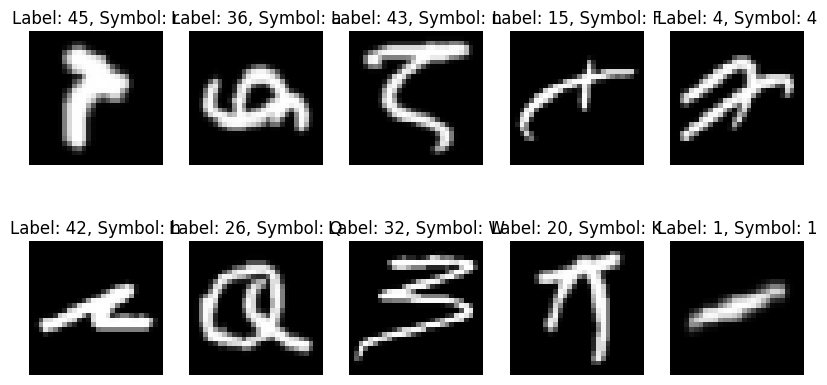

In [3]:
# Загрузка соответствий между лейблами и символами
mapping = {}
with open('emnist-balanced-mapping.txt', 'r') as f:
    for line in f:
        label, code = line.strip().split(' ')
        mapping[int(label)] = chr(int(code))

# Подсчет количества тренировочных семплов для каждого лейбла
label_counts = {}
for label in range(47):
    label_counts[label] = np.sum(labels_train == label)

# Вывод символа и количества тренировочных семплов для каждого лейбла
for label, count in label_counts.items():
    print(f'Label: {label}, Symbol: {mapping[label]}, Count: {count}')

# Отображение нескольких примеров изображений
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images_train[i], cmap='gray')
    ax.set_title(f'Label: {labels_train[i]}, Symbol: {mapping[labels_train[i]]}')
    ax.axis('off')

plt.show()

### 3. Подготовьте датасет для обучения и валидации

_Подсказка: чтобы вытянуть изображения в вектор, понадобится метод_ `reshape` _из библиотеки_ `numpy`.

In [4]:
# Преобразование в векторы
X_train = images_train.reshape(images_train.shape[0], -1)
y_train = labels_train

X_test = images_test.reshape(images_test.shape[0], -1)
y_test = labels_test

# Вывод размеров наборов
print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (112800, 784)
Test: (18800, 784)


### 4. Выберите модель, обучите её, протестируйте и сохраните

Выведите на экран точность вашей модели. Выведите и проанализируйте матрицу ошибок. Какие два символа она чаще всего путает? На каком символе модель чаще всего ошибается?

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from hyperopt import fmin, tpe, hp, Trials
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Создание модели

In [6]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

In [7]:
# Разделение на обучающий и тестовый наборы
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

# Создание наборов данных для CatBoost
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

In [8]:
# Обучение модели CatBoost с использованием GPU
model = CatBoostClassifier(
    iterations=2500,  # Количество итераций обучения
    learning_rate=0.1,  # Скорость обучения
    depth=6,  # Глубина дерева
    l2_leaf_reg=3,  # L2-регуляризация листьев
    eval_metric='Accuracy',
    task_type="GPU",  # Использование GPU
    random_seed=42,  # Случайное состояние
    # Параметры защиты от переобучения
    early_stopping_rounds=100,  # Прекращение обучения, если точность на валидационном наборе не улучшается 100 итераций
    use_best_model=True,  # Использование наилучшей модели по точности на валидационном наборе
    bagging_temperature=0.5  # Bagging для уменьшения корреляции деревьев
)

In [9]:
# Обучение модели на тренировочном наборе
model.fit(train_pool, eval_set=val_pool, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [10]:
# Предсказание на тестовом наборе
y_pred = model.predict(X_test)

# Вывод точности модели
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность: {accuracy:.4f}')

Точность: 0.8340


In [11]:

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print('\nМатрица ошибок:')
print(cm)

# Анализ матрицы ошибок
# Находим два символа, которые модель чаще всего путает
row_sums = cm.sum(axis=1, keepdims=True)
norm_cm = cm / row_sums
np.fill_diagonal(norm_cm, 0)  # обнуляем диагональ для большей ясности
max_confusions = np.unravel_index(np.argmax(norm_cm), norm_cm.shape)
symbol1 = chr(int(max_confusions[0]) + 1)
symbol2 = chr(int(max_confusions[1]) + 1)
print(f'\nДва символа, которые модель чаще всего путает: {symbol1} и {symbol2}')

# Находим символ, на котором модель чаще всего ошибается
most_confused_label = np.argmax(np.sum(cm, axis=1) - np.diag(cm))
most_confused_symbol = chr(int(most_confused_label) + 1)
print(f'\nМодель чаще всего ошибается на символе: {most_confused_symbol}')


Матрица ошибок:
[[275   0   0 ...   0   0   0]
 [  0 257   2 ...   0   0   2]
 [  0   0 335 ...   2   0   0]
 ...
 [  1   0   1 ... 217   0   4]
 [  0   0   0 ...   0 369   3]
 [  0   2   0 ...   0   5 334]]

Два символа, которые модель чаще всего путает:  и )

Модель чаще всего ошибается на символе: 


In [12]:
with open(os.path.join('myapp', 'model.pkl'),'wb') as f:
    pickle.dump(model, f)